> title : 검증데이터셋 생성 <br>
> author : jacobgreen <br>

In [1]:
! apt-get update -qq
! apt-get install fonts-nanum -qq > /dev/null

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
from tqdm.auto import tqdm

# 1. 설치된 나눔고딕 폰트 경로 확인
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 2. Matplotlib 기본 폰트로 설정
fm.fontManager.addfont(font_path)  # 폰트 추가
mpl.rc("font", family="NanumGothic")  # 폰트 설정

# 3. 한글 폰트 캐시 삭제 및 다시 로드
mpl.font_manager._load_fontmanager()

pd.set_option("display.max_columns", None)  # 모든 컬럼 출력
pd.set_option("display.max_colwidth", None)  # 컬럼 내용 생략 없음

E: Could not open lock file /var/lib/apt/lists/lock - open (13: Permission denied)
E: Unable to lock directory /var/lib/apt/lists/
W: Problem unlinking the file /var/cache/apt/pkgcache.bin - RemoveCaches (13: Permission denied)
W: Problem unlinking the file /var/cache/apt/srcpkgcache.bin - RemoveCaches (13: Permission denied)
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


/hdd_data2/yjk/miniconda3/envs/vllm-073/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_csv('dataset/train.csv', encoding = 'utf-8-sig')
test = pd.read_csv('dataset/test.csv', encoding = 'utf-8-sig')
sample = pd.read_csv("dataset/sample_submission.csv", encoding = 'utf-8-sig')

## (🔨) 데이터 전처리

In [3]:
# 데이터 전처리
# 공사종류, 공종, 사고객체 -> 대분류, 중분류로 파생
train['공사종류(대분류)'] = train['공사종류'].str.split(' / ').str[0]
train['공사종류(중분류)'] = train['공사종류'].str.split(' / ').str[1]
train['공종(대분류)'] = train['공종'].str.split(' > ').str[0]
train['공종(중분류)'] = train['공종'].str.split(' > ').str[1]
train['사고객체(대분류)'] = train['사고객체'].str.split(' > ').str[0]
train['사고객체(중분류)'] = train['사고객체'].str.split(' > ').str[1]

test['공사종류(대분류)'] = test['공사종류'].str.split(' / ').str[0]
test['공사종류(중분류)'] = test['공사종류'].str.split(' / ').str[1]
test['공종(대분류)'] = test['공종'].str.split(' > ').str[0]
test['공종(중분류)'] = test['공종'].str.split(' > ').str[1]
test['사고객체(대분류)'] = test['사고객체'].str.split(' > ').str[0]
test['사고객체(중분류)'] = test['사고객체'].str.split(' > ').str[1]

In [4]:
# 컬럼명 변경
train = train.rename(columns={'사고인지 시간':'사고인지시간'})
test = test.rename(columns={'사고인지 시간':'사고인지시간'})
train = train.rename(columns={'재발방지대책 및 향후조치계획':'재발방지대책'})
test['재발방지대책'] = None

# 컬럼 순서 정렬
feats = ['ID',
 '발생일시',
 '사고인지시간',
 '날씨',
 '기온',
 '습도',
 '공사종류',
 '연면적',
 '층 정보',
 '인적사고',
 '물적사고',
 '공종',
 '사고객체',
 '작업프로세스',
 '장소',
 '부위',
 '공사종류(대분류)',
 '공사종류(중분류)',
 '공종(대분류)',
 '공종(중분류)',
 '사고객체(대분류)',
 '사고객체(중분류)',
 '사고원인',
 '재발방지대책'
]

train = train[feats]
test = test[feats]

In [5]:
data = pd.concat([train,test]).reset_index(drop=True)
data['데이터유형'] = data['ID'].str.replace(r"\d+", "", regex=True)
data['발생일자'] = data['발생일시'].str[:10]
data['발생월'] = data['발생일시'].str[:7]
data.head(1)

,ID,발생일시,사고인지시간,날씨,기온,습도,공사종류,연면적,층 정보,인적사고,물적사고,공종,사고객체,작업프로세스,장소,부위,공사종류(대분류),공사종류(중분류),공종(대분류),공종(중분류),사고객체(대분류),사고객체(중분류),사고원인,재발방지대책,데이터유형,발생일자,발생월
0,TRAIN_00000,2023-12-31 오후 12:44,정규작업 -,맑음,1℃,30%,건축 / 건축물 / 근린생활시설,"4,892.77㎡","지상 14층, 지하 3층",떨어짐(5미터 이상 ~ 10미터 미만),없음,건축 > 철근콘크리트공사,건설자재 > 철근,설치작업,근린생활시설 / 내부,철근 / 고소,건축,건축물,건축,철근콘크리트공사,건설자재,철근,"고소작업 중 추락 위험이 있음에도 불구하고, 안전난간대, 안전고리 착용 등 안전장치가 미흡하였음.",고소작업 시 추락 위험이 있는 부위에 안전장비 설치.,TRAIN_,2023-12-31,2023-12


In [6]:
"""
사고원인 유형별 재분류

#부주의 #넘어짐 #미끄러짐 #작업미숙
"""

data['사고원인유형_알수없음'] = np.where(data['사고원인'].isin(['.','-','미상','원인미상','작업자','알수없음']),'알수없음','')
data['사고원인유형_알수없음'] = np.where(data['사고원인'].str.contains('알수없음'),'알수없음',data['사고원인유형_알수없음'])
data['사고원인유형_조사중'] = np.where(data['사고원인'].str.contains('조사|파악 중'),'조사중','')
data['사고원인유형_기타'] = np.where(data['사고원인'].str.contains('기타|해당없음'),'기타','')
data['사고원인유형_작업자부주의'] = np.where(data['사고원인'].str.contains('부주의|부주위'),'작업자부주의','')
data['사고원인유형_과실'] = np.where(data['사고원인'].str.contains('과실|실수'),'작업자부주의','')
data['사고원인유형_불안전한행동'] = np.where(data['사고원인'].str.contains('불안전한 행동|불안전한 작업자세|불안전한|불완전한|무리한|무리하게|부적절한|부적정'),'작업자부주의','')
data['사고원인유형_넘어짐'] = np.where(data['사고원인'].str.contains('넘어짐|발걸림'),'넘어짐','')
data['사고원인유형_미끄러짐'] = np.where(data['사고원인'].str.contains('미끄러'),'미끄러짐','')
data['사고원인유형_추락낙상'] = np.where(data['사고원인'].str.contains('추락|낙상'),'추락','')
data['사고원인유형_발헛디딤'] = np.where(data['사고원인'].str.contains('헛디딤|헛딛음|디뎌'),'발헛디딤','')
data['사고원인유형_작업미숙'] = np.where(data['사고원인'].str.contains('작업미숙|미숙|미흡'),'작업미숙','')
data['사고원인유형_작업방법불량'] = np.where(data['사고원인'].str.contains('작업방법 불량'),'작업방법불량','')
data['사고원인유형_근골격계질환'] = np.where(data['사고원인'].str.contains('근골격계'),'근골격계','')
data['사고원인유형_질병'] = np.where(data['사고원인'].str.contains('질병|심장마비'),'질병','')
data['사고원인유형_안전불량'] = np.where(data['사고원인'].str.contains('안전|안정|미착용|미사용|미실시|미준수|미확보|미확인|미 실시|미 확인|미설치|비규격화|전방주의 부족|확인 부족'),'안전불량','')
data['사고원인유형_오작동'] = np.where(data['사고원인'].str.contains('오작동'),'오작동','')
data['사고원인유형_작업중이동'] = np.where(data['사고원인'].str.contains('이동'),'작업중이동','')
data['사고원인유형_작업태도불량'] = np.where(data['사고원인'].str.contains('불량|주의태만|관리소홀'),'작업태도불량','')
data['사고원인유형_신호불일치'] = np.where(data['사고원인'].str.contains('불일치'),'신호불일치','')
data['사고원인유형_정리정돈'] = np.where(data['사고원인'].str.contains('정리'),'정리','')
data['사고원인유형_타격'] = np.where(data['사고원인'].str.contains('타격|타박'),'타격','')
data['사고원인유형_끼임'] = np.where(data['사고원인'].str.contains('끼임'),'끼임','')
data['사고원인유형_부딪힘'] = np.where(data['사고원인'].str.contains('부딪힘'),'부딪힘','')
data['사고원인유형_그라인더'] = np.where(data['사고원인'].str.contains('그라인더|그라인드'),'그라인더','')
data['사고원인유형_화재'] = np.where(data['사고원인'].str.contains('화재'),'화재','')
data['사고원인유형_바닥'] = np.where(data['사고원인'].str.contains('바닥'),'바닥','')
data['사고원인유형_중심잃음'] = np.where(data['사고원인'].str.contains('중심을 잃음'),'중심잃음','')
data['사고원인유형_교통사고'] = np.where(data['사고원인'].str.contains('교통'),'교통','')
data['사고원인유형_협착'] = np.where(data['사고원인'].str.contains('협착'),'협착','')
data['사고원인유형_골절'] = np.where(data['사고원인'].str.contains('골절'),'골절','')
data['사고원인유형_절단'] = np.where(data['사고원인'].str.contains('절단'),'절단','')
data['사고원인유형_손가락'] = np.where(data['사고원인'].str.contains('손가락'),'손가락','')
data['사고원인유형_발목'] = np.where(data['사고원인'].str.contains('발목'),'발목','')
data['사고원인유형_발등'] = np.where(data['사고원인'].str.contains('발등'),'발등','')
data['사고원인유형_허리'] = np.where(data['사고원인'].str.contains('허리'),'허리','')
data['사고원인유형_피로'] = np.where(data['사고원인'].str.contains('피로|쓰러짐|무리'),'피로','')

feats = [i for i in data.columns if '사고원인유형_' in i]
data['사고원인유형'] = data[feats].apply(lambda x:' '.join(sorted(x)).strip().replace(' ','|'),axis=1)
print('# 미분류:',np.round((data['사고원인유형']=='').sum()/len(data)*100,2),'%')
data['사고원인유형'] = np.where(data['사고원인유형']=='','미분류',data['사고원인유형'])

# 미분류: 18.42 %


# 📂 VALID 데이터셋 생성

[가설]
- TEST 데이터와 유사한 케이스(비슷한 사고유형)가 TRAIN 데이터에도 존재할 것이다.

In [7]:
def find_duplicate_rows(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    """
    데이터1 (train)과 데이터2 (test)에서 중복되는 행을 찾는 함수

    :param train: 비교 대상이 되는 첫 번째 데이터프레임
    :param test: 비교 대상이 되는 두 번째 데이터프레임
    :return: train과 test에서 중복되는 행을 포함하는 데이터프레임
    """
    duplicated_rows = train.merge(test, how='inner')
    duplicated_rows = duplicated_rows.drop_duplicates().reset_index(drop=True)
    return duplicated_rows

def find_duplicate_index(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    """
    데이터2 (test)에서 데이터1 (train)과 중복되는 행의 위치와 train의 인덱스를 찾는 함수

    :param train: 비교 대상이 되는 첫 번째 데이터프레임
    :param test: 비교 대상이 되는 두 번째 데이터프레임
    :return: test에서 train과 중복되는 행의 위치 (test 인덱스)와 train 인덱스
    """
    duplicated = test.merge(train.reset_index(), how='inner')
    return duplicated[['index']].set_index(duplicated.index)

In [8]:
feats = [
     '공사종류' # ,'공종' --> 중복
    ,'인적사고'
    ,'물적사고'
    ,'장소'
    ,'사고객체(대분류)'
    # ,'작업프로세스'
    # ,'부위'
    ,'사고원인유형'
]

duplicate_rows = find_duplicate_rows(
      train = data.loc[data['데이터유형']=='TRAIN_',feats]
    , test = data.loc[data['데이터유형']=='TEST_',feats]
)
print('# TRAIN:',len(data.loc[data['데이터유형']=='TRAIN_',feats]))
print('# TEST:',len(data.loc[data['데이터유형']=='TEST_',feats]))
print('# duplicate_rows:',len(duplicate_rows))

# 전략 : TRAIN데이터에서 TEST데이터와 가장 유사한 데이터셋을 VALID데이터로 생성
dupli_idx = find_duplicate_index(duplicate_rows,data.loc[data['데이터유형']=='TRAIN_',feats])
valid_idx = data.loc[data['데이터유형']=='TRAIN_',:].index.isin(dupli_idx['index'].tolist())
train_new = data.loc[data['데이터유형']=='TRAIN_',:][~valid_idx].reset_index(drop=True)
valid = data.loc[data['데이터유형']=='TRAIN_',:][valid_idx].reset_index(drop=True)
test_new = data.loc[data['데이터유형']=='TEST_',:].reset_index(drop=True)
print('# VALID:',len(valid))
print('# train_new:',len(train_new))
print('# train:',len(train))
print('# test_new:',len(test_new))

# check
valid[feats].head()

# TRAIN: 23422
# TEST: 964
# duplicate_rows: 224
# VALID: 224
# train_new: 23198
# train: 23422
# test_new: 964


,공사종류,인적사고,물적사고,장소,사고객체(대분류),사고원인유형
0,건축 / 건축물 / 근린생활시설,떨어짐(5미터 이상 ~ 10미터 미만),없음,근린생활시설 / 내부,건설자재,안전불량|작업미숙|추락
1,토목 / 터널 / 철도터널,끼임,없음,철도터널 / 내부,건설자재,작업자부주의
2,건축 / 건축물 / 업무시설,넘어짐(미끄러짐),없음,업무시설 / 내부,기타,미끄러짐|작업중이동
3,토목 / 하천 / 기타,기타,전도,기타 / 동산교 신축구간,부재,미분류
4,건축 / 건축물 / 공동주택,넘어짐(미끄러짐),없음,공동주택 / 내부,기타,작업자부주의


In [9]:
# 저장
train_new.to_csv('dataset/train_new.csv',index=False,encoding = 'utf-8-sig')
test_new.to_csv('dataset/test_new.csv',index=False,encoding = 'utf-8-sig')
valid.to_csv('dataset/valid.csv',index=False,encoding = 'utf-8-sig')

# 📂 VALID 데이터셋 분포

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


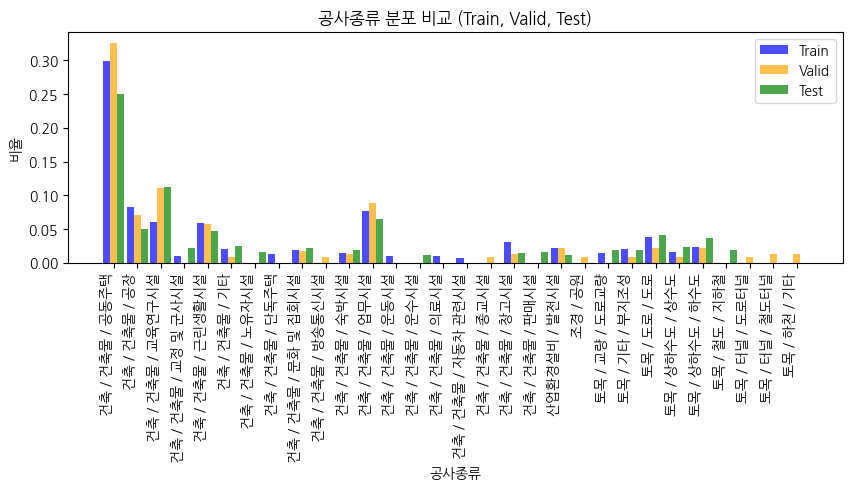

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


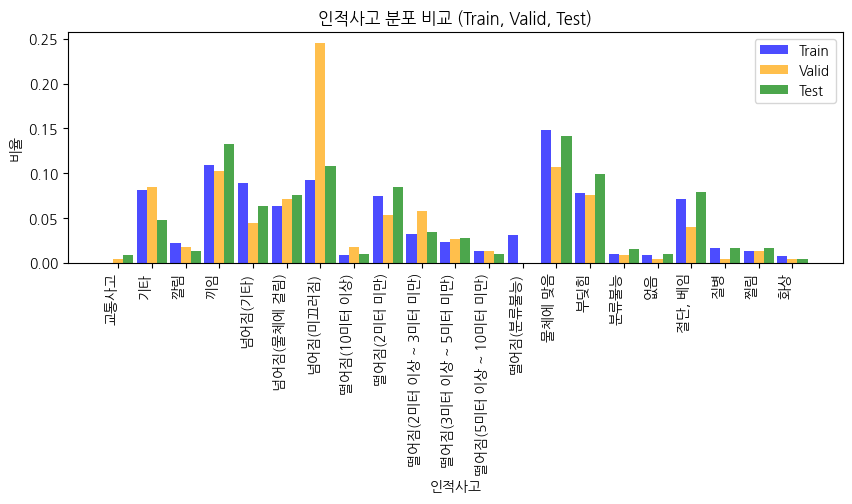

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


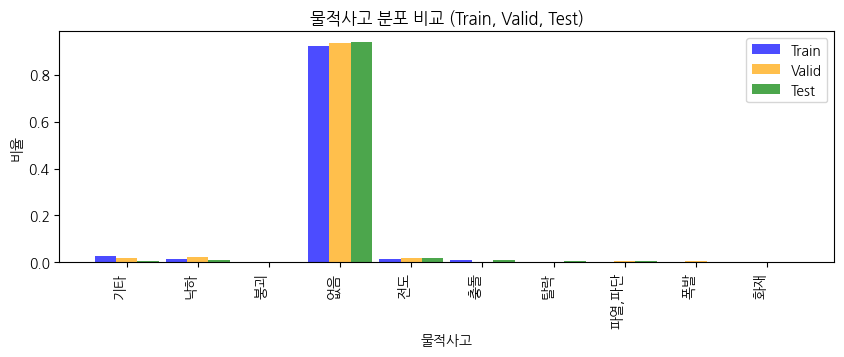

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


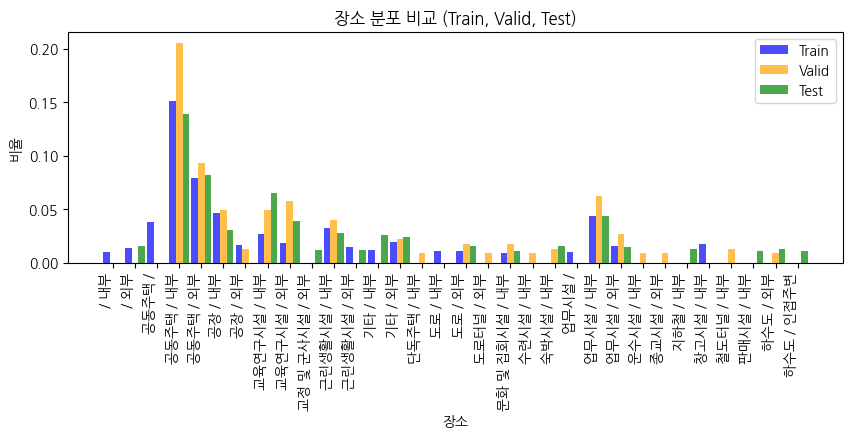

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


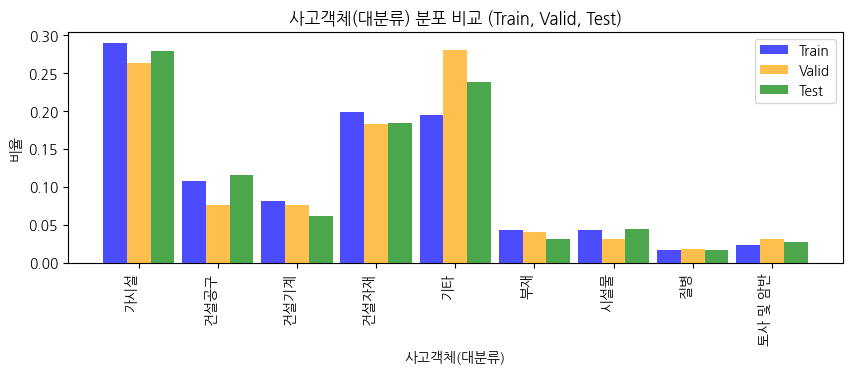

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


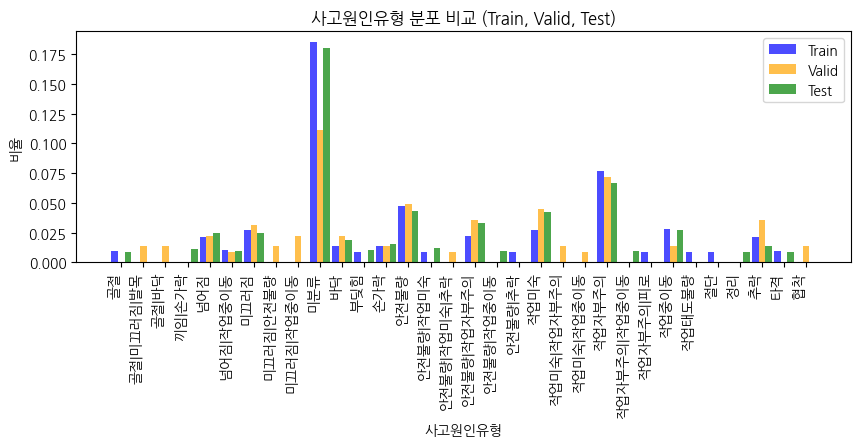

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


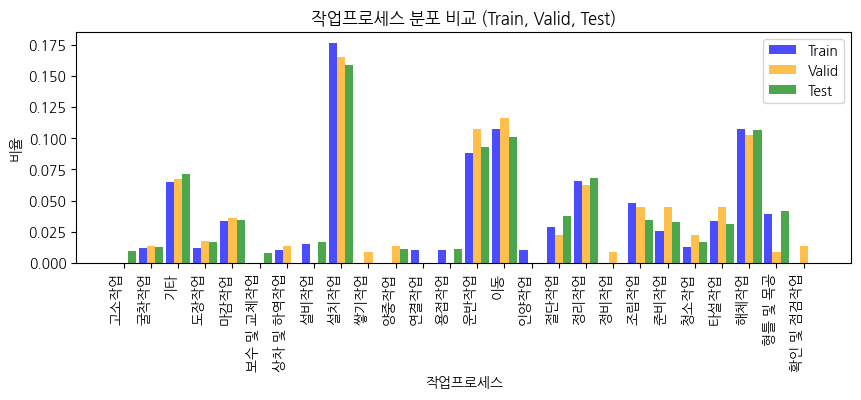

['공사종류', '인적사고', '물적사고', '장소', '사고객체(대분류)', '사고원인유형', '작업프로세스', '부위']


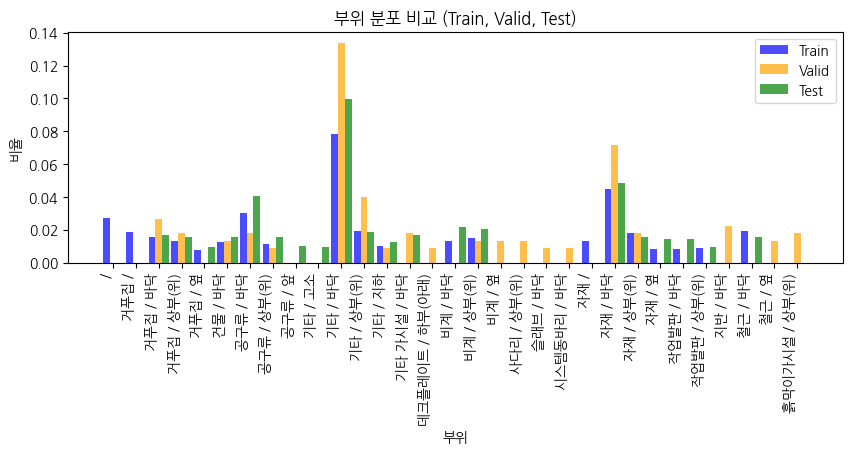

In [10]:
def make_plot1(train_new,test,valid,col):

  import numpy as np
  import matplotlib.pyplot as plt

  # 데이터 준비
  train_counts = train_new[col].value_counts(normalize=True).head(20)
  valid_counts = valid[col].value_counts(normalize=True).head(20)
  test_counts = data.loc[data['데이터유형'] == 'TEST_', col].value_counts(normalize=True).head(20)

  # 카테고리 정렬 (일관된 x축 유지)
  categories = list(set(train_counts.index) | set(valid_counts.index) | set(test_counts.index))
  categories.sort()

  # 데이터 정렬 후, NaN 값은 0으로 채우기
  train_values = [train_counts.get(cat, 0) for cat in categories]
  valid_values = [valid_counts.get(cat, 0) for cat in categories]
  test_values = [test_counts.get(cat, 0) for cat in categories]

  # 막대 그래프의 위치 조정
  x = np.arange(len(categories))  # x축 위치
  width = 0.3  # 막대 너비

  # 그래프 그리기
  plt.figure(figsize=(10, 3))

  plt.bar(x - width, train_values, width=width, label="Train", color='blue', alpha=0.7)
  plt.bar(x, valid_values, width=width, label="Valid", color='orange', alpha=0.7)
  plt.bar(x + width, test_values, width=width, label="Test", color='green', alpha=0.7)

  plt.xticks(x, categories, rotation=90, ha='right')
  plt.xlabel(col)
  plt.ylabel("비율")
  plt.title(f"{col} 분포 비교 (Train, Valid, Test)")
  plt.legend()
  plt.show()


feats = [
     '공사종류' # ,'공종' --> 중복
    ,'인적사고'
    ,'물적사고'
    ,'장소'
    ,'사고객체(대분류)'
    ,'사고원인유형'
    ,'작업프로세스'
    ,'부위'
]

for i in feats:
  print(feats)
  make_plot1(train_new,test_new,valid,i)